In [5]:
import sys, os, importlib.util
from dotenv import load_dotenv, find_dotenv

project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.insert(0, project_root)

load_dotenv(find_dotenv("../.env"), override=True)

spec = importlib.util.spec_from_file_location("connection", "../src/database/connection.py")
mod  = importlib.util.module_from_spec(spec)
spec.loader.exec_module(mod)
engine = mod.get_engine()

from sqlalchemy import text
import pandas as pd
import numpy as np
from tqdm import tqdm
from src.audio.features import extract_features

print("Ready")

Ready


In [6]:
NOISE_LEVELS = [
    ("0dB",  2),   # machine_fk matches SQL Server row
    ("-6dB", 3),
]

MACHINE_ID = "id_00"
DATA_ROOT  = "../data/raw/fan"

all_records = {}

for noise_level, machine_fk in NOISE_LEVELS:
    print(f"\n── Processing fan {noise_level} (machine_fk={machine_fk}) ──")
    
    normal_dir   = os.path.join(DATA_ROOT, noise_level, MACHINE_ID, "normal")
    abnormal_dir = os.path.join(DATA_ROOT, noise_level, MACHINE_ID, "abnormal")

    # Verify paths exist
    print(f"Normal dir exists:   {os.path.exists(normal_dir)}")
    print(f"Abnormal dir exists: {os.path.exists(abnormal_dir)}")

    records = []
    for label, folder in [("normal", normal_dir), ("abnormal", abnormal_dir)]:
        files = [f for f in os.listdir(folder) if f.endswith(".wav")]
        print(f"  {label}: {len(files)} files")

        for filename in tqdm(files, desc=f"{noise_level} {label}"):
            filepath = os.path.join(folder, filename)
            try:
                feats = extract_features(filepath)
                records.append({
                    "filename":   filename,
                    "label":      label,
                    "machine_fk": machine_fk,
                    "features":   feats
                })
            except Exception as e:
                print(f"Failed: {filename} — {e}")

    all_records[noise_level] = records
    print(f"  Total records: {len(records)}")

print("\nAll done.")


── Processing fan 0dB (machine_fk=2) ──
Normal dir exists:   True
Abnormal dir exists: True
  normal: 1011 files


0dB normal: 100%|██████████| 1011/1011 [00:42<00:00, 23.88it/s]


  abnormal: 407 files


0dB abnormal: 100%|██████████| 407/407 [00:17<00:00, 22.85it/s]


  Total records: 1418

── Processing fan -6dB (machine_fk=3) ──
Normal dir exists:   True
Abnormal dir exists: True
  normal: 1011 files


-6dB normal: 100%|██████████| 1011/1011 [00:43<00:00, 23.11it/s]


  abnormal: 407 files


-6dB abnormal: 100%|██████████| 407/407 [00:17<00:00, 23.28it/s]

  Total records: 1418

All done.


In [7]:
feature_columns = (
    [f"mfcc_mean_{i}" for i in range(1, 14)] +
    [f"mfcc_std_{i}"  for i in range(1, 14)] +
    ["spectral_centroid_mean", "spectral_centroid_std",
     "spectral_bandwidth_mean", "spectral_bandwidth_std",
     "rms_mean", "rms_std",
     "zero_crossing_rate_mean", "zero_crossing_rate_std"]
)

for noise_level, records in all_records.items():
    print(f"\nWriting {noise_level} — {len(records)} records...")

    with engine.begin() as conn:
        for record in tqdm(records, desc=noise_level):
            clip_result = conn.execute(text("""
                INSERT INTO audio_clips 
                    (machine_fk, filename, label, duration_seconds, sample_rate)
                OUTPUT INSERTED.id
                VALUES (:machine_fk, :filename, :label, 10.0, 16000)
            """), {
                "machine_fk": record["machine_fk"],
                "filename":   record["filename"],
                "label":      record["label"]
            })
            clip_id = clip_result.fetchone()[0]

            feat_dict = {"clip_fk": clip_id}
            for col, val in zip(feature_columns, record["features"]):
                feat_dict[col] = float(val)

            cols = ", ".join(feat_dict.keys())
            vals = ", ".join(f":{k}" for k in feat_dict.keys())
            conn.execute(text(f"INSERT INTO features ({cols}) VALUES ({vals})"), feat_dict)

print("\nAll noise levels written to SQL Server")

C:\Users\Kavin sagar\AppData\Local\Programs\Python\Python311\Lib\contextlib.py:137: SAWarning: Unrecognized server version info '17.0.1000.7'.  Some SQL Server features may not function properly.
  return next(self.gen)



Writing 0dB — 1418 records...


0dB: 100%|██████████| 1418/1418 [00:00<00:00, 1806.37it/s]



Writing -6dB — 1418 records...


-6dB: 100%|██████████| 1418/1418 [00:00<00:00, 1937.16it/s]


All noise levels written to SQL Server


In [9]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import roc_auc_score
import torch
import joblib
from src.models.autoencoder import FanAutoencoder

results = {}

for noise_level, machine_fk in [("0dB", 2), ("-6dB", 3)]:
    print(f"\n── Training fan {noise_level} ──")

    # Load features from DB
    with engine.connect() as conn:
        rows = conn.execute(text("""
            SELECT ac.label, f.*
            FROM features f
            JOIN audio_clips ac ON f.clip_fk = ac.id
            WHERE ac.machine_fk = :fk
        """), {"fk": machine_fk}).fetchall()

    # Build feature matrix
    labels = [r[0] for r in rows]
    X = np.array([[float(v) for v in r[3:37]] for r in rows])
    y = np.array([1 if l == "abnormal" else 0 for l in labels])

    print(f"  Samples: {len(X)} ({sum(y==0)} normal, {sum(y==1)} abnormal)")

    X_normal = X[y == 0]
    scaler   = StandardScaler()
    X_normal_scaled = scaler.fit_transform(X_normal)
    X_scaled        = scaler.transform(X)

    # ── Isolation Forest ──
    iso = IsolationForest(n_estimators=200, contamination=0.05,
                          random_state=42, n_jobs=-1)
    iso.fit(X_normal_scaled)
    iso_scores = -iso.decision_function(X_scaled)
    iso_auc    = roc_auc_score(y, iso_scores)
    print(f"  Isolation Forest AUC: {iso_auc:.4f}")

    # ── Autoencoder ──
    import torch.nn as nn
    from torch.utils.data import DataLoader, TensorDataset

    X_normal_tensor = torch.FloatTensor(X_normal_scaled)
    X_all_tensor    = torch.FloatTensor(X_scaled)

    train_loader = DataLoader(
        TensorDataset(X_normal_tensor),
        batch_size=32, shuffle=True
    )

    ae = FanAutoencoder(input_dim=34)
    opt = torch.optim.Adam(ae.parameters(), lr=1e-3, weight_decay=1e-5)
    criterion = nn.MSELoss()

    ae.train()
    for epoch in range(100):
        for (batch,) in train_loader:
            opt.zero_grad()
            loss = criterion(ae(batch), batch)
            loss.backward()
            opt.step()

    ae.eval()
    ae_errors = ae.reconstruction_error(X_all_tensor).numpy()
    ae_auc    = roc_auc_score(y, ae_errors)
    print(f"  Autoencoder AUC:      {ae_auc:.4f}")

    # Save models
    torch.save(ae.state_dict(),
               f"../models_saved/autoencoder_{noise_level.replace('-','min')}.pt")
    joblib.dump(scaler,
                f"../models_saved/scaler_{noise_level.replace('-','min')}.joblib")

    results[noise_level] = {
        "iso_auc": iso_auc,
        "ae_auc":  ae_auc,
        "y":       y,
        "iso_scores": iso_scores,
        "ae_errors":  ae_errors,
        "machine_fk": machine_fk,
        "X_scaled":   X_scaled,
        "iso_model":  iso,
        "scaler":     scaler
    }

print("\n── Summary ──")
print(f"{'Noise':<8} {'IF AUC':<10} {'AE AUC':<10}")
print(f"{'6dB':<8} {'0.8549':<10} {'0.9216':<10}")
for nl, r in results.items():
    print(f"{nl:<8} {r['iso_auc']:.4f}     {r['ae_auc']:.4f}")


── Training fan 0dB ──
  Samples: 1418 (1011 normal, 407 abnormal)
  Isolation Forest AUC: 0.6964
  Autoencoder AUC:      0.8110

── Training fan -6dB ──
  Samples: 1418 (1011 normal, 407 abnormal)
  Isolation Forest AUC: 0.5896
  Autoencoder AUC:      0.6845

── Summary ──
Noise    IF AUC     AE AUC    
6dB      0.8549     0.9216    
0dB      0.6964     0.8110
-6dB     0.5896     0.6845


In [10]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.preprocessing import MinMaxScaler

# ── Store predictions to SQL Server ──
for noise_level, r in results.items():
    print(f"Storing {noise_level} predictions...")

    with engine.connect() as conn:
        clip_rows = conn.execute(text("""
            SELECT id FROM audio_clips
            WHERE machine_fk = :fk
            ORDER BY id
        """), {"fk": r["machine_fk"]}).fetchall()

    clip_ids = [row[0] for row in clip_rows]

    # Normalise scores
    ae_norm = MinMaxScaler().fit_transform(
        r["ae_errors"].reshape(-1,1)).flatten()
    iso_norm = MinMaxScaler().fit_transform(
        r["iso_scores"].reshape(-1,1)).flatten()

    y_pred_ae  = (ae_norm  > np.percentile(ae_norm,  90)).astype(int)
    y_pred_iso = (iso_norm > np.percentile(iso_norm, 90)).astype(int)

    with engine.begin() as conn:
        for clip_id, ae_s, iso_s, ae_p, iso_p, true in zip(
            clip_ids, ae_norm, iso_norm, y_pred_ae, y_pred_iso, r["y"]
        ):
            for model_name, score, pred in [
                ("autoencoder",      ae_s,  ae_p),
                ("isolation_forest", iso_s, iso_p)
            ]:
                conn.execute(text("""
                    INSERT INTO predictions
                        (clip_fk, model_name, anomaly_score, predicted_label, true_label)
                    VALUES
                        (:clip_fk, :model, :score, :pred, :true)
                """), {
                    "clip_fk": clip_id,
                    "model":   model_name,
                    "score":   float(score),
                    "pred":    "abnormal" if pred == 1 else "normal",
                    "true":    "abnormal" if true == 1 else "normal"
                })

    print(f"  {noise_level} done — {len(clip_ids)*2} predictions stored")

print("\nAll predictions stored")

Storing 0dB predictions...
  0dB done — 2836 predictions stored
Storing -6dB predictions...
  -6dB done — 2836 predictions stored

All predictions stored


In [15]:
import joblib
import torch
from src.models.autoencoder import FanAutoencoder

# Reload 6dB scaler and model
scaler_6db = joblib.load("../models_saved/scaler_autoencoder.joblib")
ae_6db = FanAutoencoder(input_dim=34)
ae_6db.load_state_dict(torch.load("../models_saved/autoencoder.pt", map_location="cpu"))
ae_6db.eval()

# Load 6dB features from DB
with engine.connect() as conn:
    rows_6db = conn.execute(text("""
        SELECT ac.label, f.*
        FROM features f
        JOIN audio_clips ac ON f.clip_fk = ac.id
        WHERE ac.machine_fk = 1
    """)).fetchall()

labels_6db = [r[0] for r in rows_6db]
X_6db = np.array([[float(v) for v in r[3:37]] for r in rows_6db])
y_6db = np.array([1 if l == "abnormal" else 0 for l in labels_6db])

X_6db_scaled = scaler_6db.transform(X_6db)
tensor_6db   = torch.FloatTensor(X_6db_scaled)
errors_6db   = ae_6db.reconstruction_error(tensor_6db).numpy()

# Add to results so the plot picks it up
results["6dB"] = {
    "ae_errors":  errors_6db,
    "y":          y_6db,
    "machine_fk": 1
}

print(f"6dB loaded: {len(errors_6db)} samples")

6dB loaded: 1418 samples


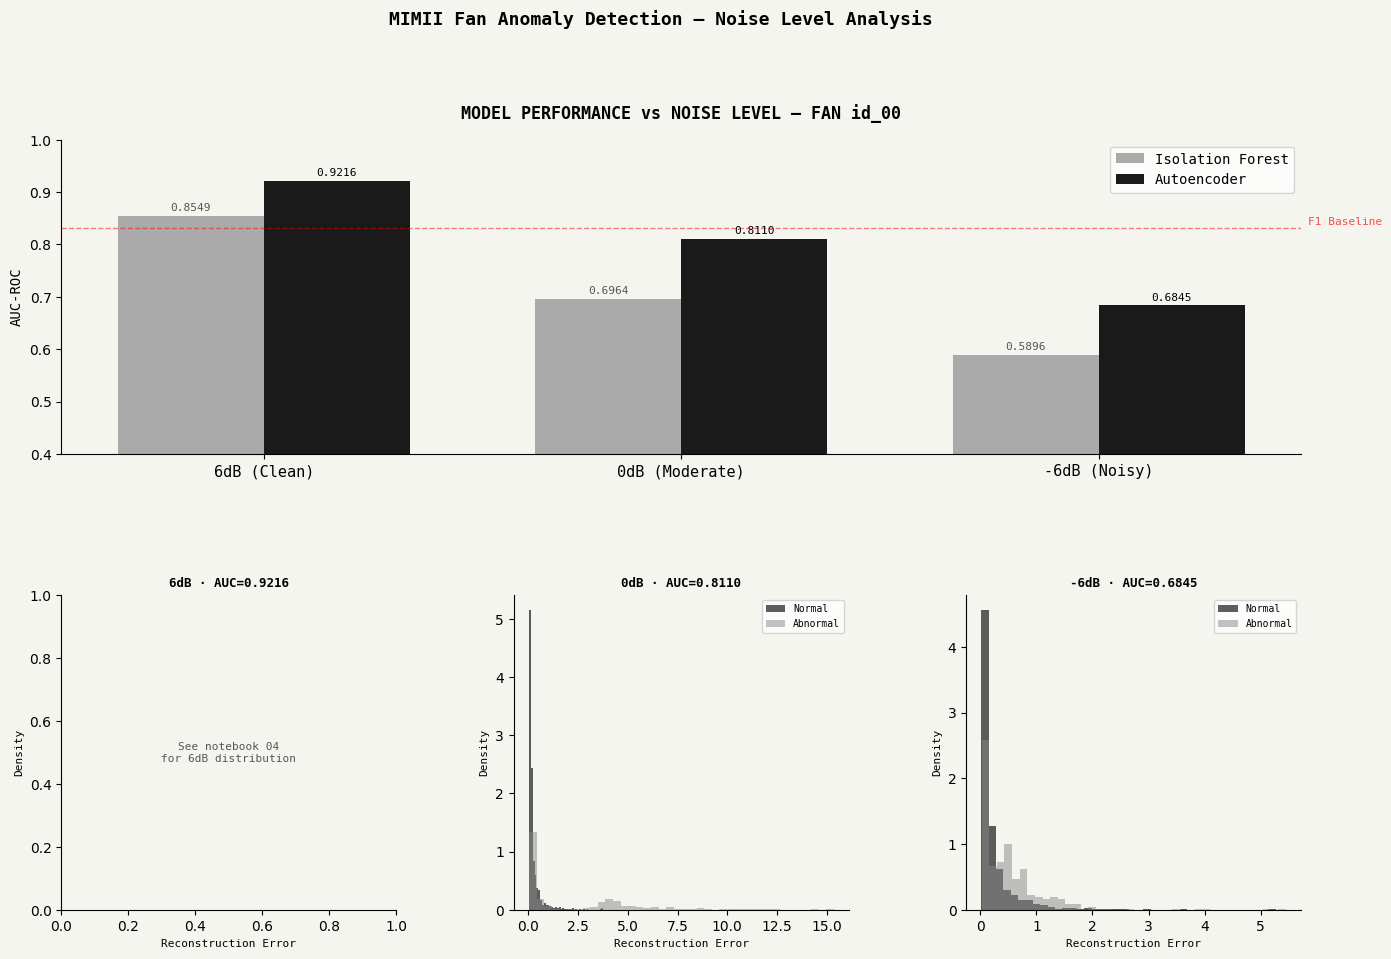

Plot saved


In [ ]:
fig = plt.figure(figsize=(16, 10))
fig.patch.set_facecolor('#f5f5f0')
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

noise_levels_all = [("6dB", 0.8549, 0.9216), ("0dB", 0.6964, 0.8110), ("-6dB", 0.5896, 0.6845)]
colors = ['#1a1a1a', '#555555', '#aaaaaa']

# ── Top: AUC comparison bar chart ──
ax_main = fig.add_subplot(gs[0, :])
x      = np.arange(3)
width  = 0.35
bars1  = ax_main.bar(x - width/2, [r[1] for r in noise_levels_all],
                      width, label='Isolation Forest', color='#aaaaaa')
bars2  = ax_main.bar(x + width/2, [r[2] for r in noise_levels_all],
                      width, label='Autoencoder', color='#1a1a1a')

ax_main.set_xticks(x)
ax_main.set_xticklabels(['6dB (Clean)', '0dB (Moderate)', '-6dB (Noisy)'],
                          fontfamily='monospace', fontsize=11)
ax_main.set_ylim(0.4, 1.0)
ax_main.set_ylabel('AUC-ROC', fontfamily='monospace')
ax_main.set_title('MODEL PERFORMANCE vs NOISE LEVEL — FAN id_00',
                    fontfamily='monospace', fontsize=12, fontweight='bold', pad=15)
ax_main.axhline(0.831, color='red', linestyle='--', alpha=0.5, linewidth=1)
ax_main.text(2.5, 0.838, 'F1 Baseline', fontfamily='monospace',
              fontsize=8, color='red', alpha=0.7)
ax_main.legend(prop={'family':'monospace'})
ax_main.set_facecolor('#f5f5f0')
ax_main.spines[['top','right']].set_visible(False)

# Add value labels on bars
for bar in bars1:
    ax_main.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                  f'{bar.get_height():.4f}', ha='center', va='bottom',
                  fontfamily='monospace', fontsize=8, color='#555555')
for bar in bars2:
    ax_main.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                  f'{bar.get_height():.4f}', ha='center', va='bottom',
                  fontfamily='monospace', fontsize=8)

# ── Bottom: Score distributions for each noise level ──
ae_6db_errors = results.get("6dB", {}).get("ae_errors", None)

noise_data = [
    ("6dB",  results["6dB"]["ae_errors"],  0.9216),
    ("0dB",  results["0dB"]["ae_errors"],  0.8110),
    ("-6dB", results["-6dB"]["ae_errors"], 0.6845),
]

for i, (nl, errors, auc) in enumerate(noise_data):
    ax = fig.add_subplot(gs[1, i])

    if errors is not None:
        y_nl = results[nl]["y"]
        ax.hist(errors[y_nl==0], bins=40, alpha=0.7,
                color='#1a1a1a', label='Normal', density=True)
        ax.hist(errors[y_nl==1], bins=40, alpha=0.5,
                color='#888888', label='Abnormal', density=True)
    else:
        ax.text(0.5, 0.5, 'See notebook 04\nfor 6dB distribution',
                ha='center', va='center', transform=ax.transAxes,
                fontfamily='monospace', fontsize=8, color='#555555')

    ax.set_title(f'{nl} · AUC={auc:.4f}',
                  fontfamily='monospace', fontsize=9, fontweight='bold')
    ax.set_xlabel('Reconstruction Error', fontfamily='monospace', fontsize=8)
    ax.set_ylabel('Density', fontfamily='monospace', fontsize=8)
    ax.set_facecolor('#f5f5f0')
    ax.spines[['top','right']].set_visible(False)
    if errors is not None:
        ax.legend(prop={'family':'monospace', 'size':7})

plt.suptitle('MIMII Fan Anomaly Detection — Noise Level Analysis',
              fontfamily='monospace', fontsize=13, fontweight='bold', y=1.01)

plt.savefig("../data/processed/noise_level_comparison.png",
             dpi=150, bbox_inches='tight', facecolor='#f5f5f0')
plt.show()
print("Plot saved")